# Train Core Observation Only

Ablation run retaining only the core observation features (`x`, `log_y`, `log_e`, `r`).


In [18]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import numpy as np
from scipy.stats import norm as scipy_norm, invgamma
from scipy.stats import beta as scipy_beta
from scipy.stats import halfnorm
import matplotlib.pyplot as plt
import bayesflow as bf
import keras
import pickle
from pathlib import Path

np.random.seed(123)
np.set_printoptions(suppress=True)

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Helper functions
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
from scipy.spatial import Delaunay

def _random_adjacency(N):
    """
    Generates a realistic spatial adjacency matrix A 
    using Delaunay Triangulation (planar graph).
    """
    # 1. Drop N random coordinates in a 2D space
    points = np.random.uniform(0, 10, size=(N, 2))
    
    # 2. Compute Delaunay Triangulation (creates non-overlapping triangles)
    tri = Delaunay(points)
    
    # 3. Build the Adjacency Matrix A from the triangle edges
    A = np.zeros((N, N), dtype=int)
    for simplex in tri.simplices:
        # simplex contains the indices of the 3 points forming a triangle
        for i in range(3):
            for j in range(i + 1, 3):
                n1, n2 = simplex[i], simplex[j]
                A[n1, n2] = 1
                A[n2, n1] = 1  # Make it symmetric
                
    return A

def _dagar_factors(A, rho, ordering):
    """
    Compute the DAGAR factors (ImB, lam) without forming Q explicitly.
 
    Q(rho) = (I-B)^T diag(lam) (I-B)
 
    Returns
    -------
    ImB : (n, n)  unit lower-triangular matrix (I - B)
    lam : (n,)    diagonal entries of Lambda
 
    Sampling w ~ N(0, sigma2_w * Q^{-1}) is then done via triangular solve:
        z   ~ N(0, I)
        rhs = sqrt(sigma2_w) * z / sqrt(lam)     [scale by Lambda^{-1/2}]
        w   = solve(ImB, rhs)                     [O(N^2) back-substitution]
    which avoids forming Q or its inverse entirely.
    """
    n    = A.shape[0]
    rho2 = rho ** 2
    inv_order = np.argsort(ordering)
 
    B   = np.zeros((n, n))
    lam = np.zeros(n)
 
    for pos in range(n):
        i     = ordering[pos]
        preds = [ordering[q] for q in range(pos) if A[i, ordering[q]] == 1]
        n_lt  = len(preds)
        denom = 1.0 + max(n_lt - 1, 0) * rho2
        b_val = rho / denom if n_lt > 0 else 0.0
        for j in preds:
            B[pos, inv_order[j]] = b_val
        lam[pos] = denom / (1.0 - rho2)
 
    ImB = np.eye(n) - B   # unit lower-triangular
    return ImB, lam

In [20]:
import warnings

# con rho ed N fissati funziona

ETA_RAW_LOWER = 0.0

EXPERIMENT_NAME = "06_core_observation_only"
ABLATION_LABEL = "core_observation_only"
ABLATION_FEATURE_NAMES = ['degree', 'r_lag_all', 'absdiff_all', 'r_lag_low', 'r_lag_mid', 'r_lag_high', 'absdiff_low', 'absdiff_mid', 'absdiff_high', 'prop_low', 'prop_mid', 'prop_high', 'mean_z_rel', 'max_z_rel', 'local_moran', 'local_semivar', 'M', 'edge_absdiff_slope', 'edge_absdiff_gap', 'edge_concord_gap', 'edge_corr_all', 'lag_corr_all', 'lag_slope_all', 'edge_semivar_all']
FULL_SUMMARY_FEATURE_NAMES = [
    "x",
    "log_y",
    "log_e",
    "r",
    "degree",
    "r_lag_all",
    "absdiff_all",
    "r_lag_low",
    "r_lag_mid",
    "r_lag_high",
    "absdiff_low",
    "absdiff_mid",
    "absdiff_high",
    "prop_low",
    "prop_mid",
    "prop_high",
    "mean_z_rel",
    "max_z_rel",
    "local_moran",
    "local_semivar",
    "M",
    "edge_absdiff_slope",
    "edge_absdiff_gap",
    "edge_concord_gap",
    "edge_corr_all",
    "lag_corr_all",
    "lag_slope_all",
    "edge_semivar_all",
]
ABLATION_FEATURE_INDICES = [
    FULL_SUMMARY_FEATURE_NAMES.index(name) for name in ABLATION_FEATURE_NAMES
]

# Smaller regime for ablation experiments
TRAIN_EPOCHS = 40
TRAIN_BATCH_SIZE = 64
TRAIN_NUM_BATCHES = 100
VALIDATION_BATCH_SIZE = 64
VALIDATION_NUM_BATCHES = 16
MODEL_INIT_SEED = 123
SHARED_TRAIN_BATCH_SEED = 2026051201
SHARED_VALIDATION_BATCH_SEED = 2026051202

# Toggle this flag only for N
USE_FIXED_N = False

ORDERING_MODE = "identity"   # "identity", "random", "x_sorted"

# Used when USE_FIXED_N = True
N_FIXED = 100

# Used when USE_FIXED_N = False
N_MIN = 40
N_MAX = 120

SHARED_DATA_ROOT = Path("C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Simulation Experiments/Ablation_experiments/Results/shared_data")
SHARED_TRAIN_BATCHES_PATH = SHARED_DATA_ROOT / "train_batches_full_summaries_b100_bs64_n40_120_seed2026051201.pkl"
SHARED_VALIDATION_BATCHES_PATH = SHARED_DATA_ROOT / "validation_batches_full_summaries_b16_bs64_n40_120_seed2026051202.pkl"

# If you already loaded a fixed adjacency matrix A earlier in the notebook,
# the simulator will use it. Otherwise it will generate a random adjacency.
if "A" in globals():
    A_GLOBAL = np.asarray(A, dtype=np.float32)
    N_FIXED = int(A_GLOBAL.shape[0])
else:
    A_GLOBAL = None
    N_FIXED = 100


def _get_simulation_adjacency(N):
    if A_GLOBAL is not None:
        if A_GLOBAL.shape[0] != N:
            raise ValueError(f"A has shape {A_GLOBAL.shape}, but N={N}.")
        return A_GLOBAL.copy()
    return _random_adjacency(N).astype(np.float32)

"""
def _deterministic_ordering(A):
    # Current recommendation: fixed identity ordering.
    # This matched the clearest eta signal in your diagnostics.
    return np.arange(A.shape[0], dtype=int)
"""

def _get_ordering(A):
    n = A.shape[0]

    if ORDERING_MODE == "random":
        return np.random.permutation(n).astype(int)
    if ORDERING_MODE == "identity":
        return np.arange(n, dtype=int)

    raise ValueError(f"Unknown ORDERING_MODE: {ORDERING_MODE}")

def _repair_isolates_deterministic(A_filtered, A, Z):
    A_rep = A_filtered.copy().astype(np.float32)
    for i in range(A_rep.shape[0]):
        if A_rep[i].sum() == 0:
            neighbors = np.where(A[i] == 1)[0]
            if len(neighbors) > 0:
                # Reconnect to the most similar observed neighbor
                j = neighbors[np.argmin(Z[i, neighbors])]
                A_rep[i, j] = 1.0
                A_rep[j, i] = 1.0
    return A_rep


def _masked_row_mean(values, mask):
    mask_f = mask.astype(np.float32)
    denom = mask_f.sum(axis=1)
    denom_safe = np.where(denom == 0, 1.0, denom)
    out = (values * mask_f).sum(axis=1) / denom_safe
    out[denom == 0] = 0.0
    return out.astype(np.float32)


def _safe_mean_1d(values):
    return float(values.mean()) if values.size > 0 else 0.0

print(EXPERIMENT_NAME)
print("Retained core features:", ["x", "log_y", "log_e", "r"])
print("Retained core features:", ["x", "log_y", "log_e", "r"])
print("Ablated features:", ABLATION_FEATURE_NAMES)
print("Feature indices:", ABLATION_FEATURE_INDICES)
print(f"Training N range: [{N_MIN}, {N_MAX}]")
print(f"Train batches x batch size: {TRAIN_NUM_BATCHES} x {TRAIN_BATCH_SIZE}")
print(f"Validation batches x batch size: {VALIDATION_NUM_BATCHES} x {VALIDATION_BATCH_SIZE}")


06_core_observation_only
Retained core features: ['x', 'log_y', 'log_e', 'r']
Retained core features: ['x', 'log_y', 'log_e', 'r']
Ablated features: ['degree', 'r_lag_all', 'absdiff_all', 'r_lag_low', 'r_lag_mid', 'r_lag_high', 'absdiff_low', 'absdiff_mid', 'absdiff_high', 'prop_low', 'prop_mid', 'prop_high', 'mean_z_rel', 'max_z_rel', 'local_moran', 'local_semivar', 'M', 'edge_absdiff_slope', 'edge_absdiff_gap', 'edge_concord_gap', 'edge_corr_all', 'lag_corr_all', 'lag_slope_all', 'edge_semivar_all']
Feature indices: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Training N range: [40, 120]
Train batches x batch size: 100 x 64
Validation batches x batch size: 16 x 64


In [21]:
def _safe_corr(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    x_c = x - x.mean()
    y_c = y - y.mean()

    denom = np.sqrt(np.mean(x_c ** 2) * np.mean(y_c ** 2))
    if denom < 1e-8:
        return 0.0
    return float(np.mean(x_c * y_c) / denom)


def _apply_feature_ablation(obs_full, drop_feature_indices=None):
    obs_full = np.asarray(obs_full, dtype=np.float32)
    if not drop_feature_indices:
        return obs_full.astype(np.float32)
    return np.delete(obs_full, drop_feature_indices, axis=-1).astype(np.float32)


def _observed_eta_signal_metrics(y, e, A, Z, Z_median, r_lag_all=None):
    A_bool = A == 1
    edge_i, edge_j = np.where(np.triu(A_bool, 1))

    zero_metrics = dict(
        edge_absdiff_low=0.0,
        edge_absdiff_mid=0.0,
        edge_absdiff_high=0.0,
        edge_concord_low=0.0,
        edge_concord_mid=0.0,
        edge_concord_high=0.0,
        edge_absdiff_slope=0.0,
        edge_absdiff_gap=0.0,
        edge_concord_gap=0.0,
        edge_corr_all=0.0,
        lag_corr_all=0.0,
        lag_slope_all=0.0,
        edge_semivar_all=0.0,
        local_moran_mean=0.0,
    )
    if edge_i.size == 0:
        return zero_metrics

    r = (np.log(y + 0.5) - np.log(e)).astype(np.float32)
    z_rel = (Z / Z_median).astype(np.float32)

    z_edge = z_rel[edge_i, edge_j]
    absdiff_edge = np.abs(r[edge_i] - r[edge_j]).astype(np.float32)
    sqdiff_edge = ((r[edge_i] - r[edge_j]) ** 2).astype(np.float32)

    r_centered = (r - r.mean()).astype(np.float32)
    var_r = float(np.mean(r_centered ** 2))
    var_r_safe = max(var_r, 1e-8)

    concord_edge = (r_centered[edge_i] * r_centered[edge_j]).astype(np.float32)

    low = z_edge <= 0.75
    mid = (z_edge > 0.75) & (z_edge <= 1.25)
    high = z_edge > 1.25

    z_bar = float(z_edge.mean())
    absdiff_bar = float(absdiff_edge.mean())
    var_z = float(np.mean((z_edge - z_bar) ** 2))

    if var_z < 1e-8:
        edge_absdiff_slope = 0.0
    else:
        edge_absdiff_slope = float(
            np.mean((z_edge - z_bar) * (absdiff_edge - absdiff_bar)) / var_z
        )

    if r_lag_all is None:
        degree = A_bool.sum(axis=1).astype(np.float32)
        degree_safe = np.where(degree == 0, 1.0, degree)
        W = A / degree_safe[:, None]
        r_lag_all = (W @ r).astype(np.float32)

    r_lag_centered = (r_lag_all - r_lag_all.mean()).astype(np.float32)
    lag_slope_all = float(np.mean(r_centered * r_lag_centered) / var_r_safe)
    lag_corr_all = _safe_corr(r, r_lag_all)

    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    edge_corr_all = float(np.mean(concord_edge) / var_r_safe)
    edge_semivar_all = float(0.5 * np.mean(sqdiff_edge))

    return dict(
        edge_absdiff_low=_safe_mean_1d(absdiff_edge[low]),
        edge_absdiff_mid=_safe_mean_1d(absdiff_edge[mid]),
        edge_absdiff_high=_safe_mean_1d(absdiff_edge[high]),
        edge_concord_low=_safe_mean_1d(concord_edge[low]),
        edge_concord_mid=_safe_mean_1d(concord_edge[mid]),
        edge_concord_high=_safe_mean_1d(concord_edge[high]),
        edge_absdiff_slope=edge_absdiff_slope,
        edge_absdiff_gap=_safe_mean_1d(absdiff_edge[high]) - _safe_mean_1d(absdiff_edge[low]),
        edge_concord_gap=_safe_mean_1d(concord_edge[low]) - _safe_mean_1d(concord_edge[high]),
        edge_corr_all=edge_corr_all,
        lag_corr_all=lag_corr_all,
        lag_slope_all=lag_slope_all,
        edge_semivar_all=edge_semivar_all,
        local_moran_mean=float(local_moran.mean()),
    )


def _build_full_observed_features(x, y, e, A, Z, Z_median, M):
    A_bool = A == 1

    x = x.astype(np.float32)
    y = y.astype(np.float32)
    e = e.astype(np.float32)

    log_y = np.log1p(y).astype(np.float32)
    log_e = np.log(e).astype(np.float32)
    r = (np.log(y + 0.5) - log_e).astype(np.float32)

    r_centered = (r - r.mean()).astype(np.float32)
    var_r_safe = max(float(np.mean(r_centered ** 2)), 1e-8)

    degree = A_bool.sum(axis=1).astype(np.float32)
    degree_safe = np.where(degree == 0, 1.0, degree)

    z_rel = (Z / Z_median).astype(np.float32)
    neigh_r = np.broadcast_to(r[None, :], z_rel.shape).astype(np.float32)
    abs_r_diff = np.abs(r[:, None] - r[None, :]).astype(np.float32)

    low_mask = A_bool & (z_rel <= 0.75)
    mid_mask = A_bool & (z_rel > 0.75) & (z_rel <= 1.25)
    high_mask = A_bool & (z_rel > 1.25)

    r_lag_all = _masked_row_mean(neigh_r, A_bool)
    absdiff_all = _masked_row_mean(abs_r_diff, A_bool)

    r_lag_low = _masked_row_mean(neigh_r, low_mask)
    r_lag_mid = _masked_row_mean(neigh_r, mid_mask)
    r_lag_high = _masked_row_mean(neigh_r, high_mask)

    absdiff_low = _masked_row_mean(abs_r_diff, low_mask)
    absdiff_mid = _masked_row_mean(abs_r_diff, mid_mask)
    absdiff_high = _masked_row_mean(abs_r_diff, high_mask)

    prop_low = (low_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_mid = (mid_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_high = (high_mask.sum(axis=1) / degree_safe).astype(np.float32)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_z_rel = np.nanmean(np.where(A_bool, z_rel, np.nan), axis=1)
        max_z_rel = np.nanmax(np.where(A_bool, z_rel, np.nan), axis=1)

    mean_z_rel = np.nan_to_num(mean_z_rel, nan=0.0).astype(np.float32)
    max_z_rel = np.nan_to_num(max_z_rel, nan=0.0).astype(np.float32)

    edge_metrics = _observed_eta_signal_metrics(
        y=y,
        e=e,
        A=A,
        Z=Z,
        Z_median=Z_median,
        r_lag_all=r_lag_all,
    )

    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    local_semivar = (((r - r_lag_all) ** 2) / var_r_safe).astype(np.float32)

    obs_full = np.stack(
        [
            x,
            #y,
            #e,
            log_y,
            log_e,
            r,
            degree,
            r_lag_all,
            absdiff_all,
            r_lag_low,
            r_lag_mid,
            r_lag_high,
            absdiff_low,
            absdiff_mid,
            absdiff_high,
            prop_low,
            prop_mid,
            prop_high,
            mean_z_rel,
            max_z_rel,
            local_moran,
            local_semivar,
            np.full(len(x), M, dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_slope"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_concord_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_slope_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_semivar_all"], dtype=np.float32),
        ],
        axis=-1,
    ).astype(np.float32)

    return obs_full.astype(np.float32)


def _build_observed_features(x, y, e, A, Z, Z_median, M):
    obs_full = _build_full_observed_features(x=x, y=y, e=e, A=A, Z=Z, Z_median=Z_median, M=M)
    return _apply_feature_ablation(obs_full, ABLATION_FEATURE_INDICES)


In [22]:
def prior():
    beta_0 = np.random.normal(0.0, 0.5)
    sigma2_w = halfnorm.rvs(scale=0.5)
    eta_raw = np.random.uniform(ETA_RAW_LOWER, 1.0)
    rho = np.random.uniform(0.0, 1.0)
    return dict(
        beta=np.array([beta_0], dtype=np.float32),
        sigma2_w=np.array([sigma2_w], dtype=np.float32),
        eta_raw=np.array([eta_raw], dtype=np.float32),
        rho=np.array([rho], dtype=np.float32),
    )


def likelihood(beta, sigma2_w, eta_raw, rho, N):
    beta_0 = float(beta[0])
    sigma2_w = float(sigma2_w[0])
    eta_raw_val = float(eta_raw[0])
    rho_val = float(rho[0])
    N = int(N)

    A_sim = _get_simulation_adjacency(int(N)).astype(np.float32)

    x = np.random.normal(0.0, 1.0, size=N).astype(np.float32)
    Z = np.abs(x[:, None] - x[None, :]).astype(np.float32)

    Z_edges = Z[A_sim == 1]
    if Z_edges.size == 0:
        Z_median = 1.0
    else:
        Z_median = float(np.median(Z_edges) + 1e-8)

    M = float(np.log(2.0) / Z_median)
    eta = float(eta_raw_val * M)

    A_filtered = A_sim * ((Z * eta) <= np.log(2.0)).astype(np.float32)
    A_filtered = _repair_isolates_deterministic(A_filtered, A_sim, Z)

    ordering = _get_ordering(A_sim)
    
    ImB, dagar_lam = _dagar_factors(A_filtered, rho_val, ordering) #RHO_VAL
    z = np.random.normal(size=N).astype(np.float32)
    rhs = np.sqrt(sigma2_w) * z / np.sqrt(dagar_lam)
    w = np.linalg.solve(ImB, rhs).astype(np.float32)
    w = w - np.mean(w)

    # e = np.random.uniform(50.0, 150.0, size=N).astype(np.float32)
    log_e = np.random.uniform(np.log(2.0), np.log(30000.0), size=N)
    e = np.exp(log_e).astype(np.float32)

    log_poisson_lam = np.log(e) + beta_0 + w
    poisson_lam = np.clip(np.exp(log_poisson_lam), 1e-2, 1e6)
    y = np.random.poisson(poisson_lam).astype(np.float32)

    obs = _build_observed_features(
        x=x,
        y=y,
        e=e,
        A=A_sim,
        Z=Z,
        Z_median=Z_median,
        M=M,
    )

    return dict(
        obs=obs,
        M=np.array([M], dtype=np.float32),
        A=A_sim.astype(np.float32),
        A_filtered=A_filtered.astype(np.float32),
    )


def likelihood_full(beta, sigma2_w, eta_raw, rho, N):
    beta_0 = float(beta[0])
    sigma2_w = float(sigma2_w[0])
    eta_raw_val = float(eta_raw[0])
    rho_val = float(rho[0])
    N = int(N)

    A_sim = _get_simulation_adjacency(int(N)).astype(np.float32)

    x = np.random.normal(0.0, 1.0, size=N).astype(np.float32)
    Z = np.abs(x[:, None] - x[None, :]).astype(np.float32)

    Z_edges = Z[A_sim == 1]
    if Z_edges.size == 0:
        Z_median = 1.0
    else:
        Z_median = float(np.median(Z_edges) + 1e-8)

    M = float(np.log(2.0) / Z_median)
    eta = float(eta_raw_val * M)

    A_filtered = A_sim * ((Z * eta) <= np.log(2.0)).astype(np.float32)
    A_filtered = _repair_isolates_deterministic(A_filtered, A_sim, Z)

    ordering = _get_ordering(A_sim)

    ImB, dagar_lam = _dagar_factors(A_filtered, rho_val, ordering)
    z = np.random.normal(size=N).astype(np.float32)
    rhs = np.sqrt(sigma2_w) * z / np.sqrt(dagar_lam)
    w = np.linalg.solve(ImB, rhs).astype(np.float32)
    w = w - np.mean(w)

    log_e = np.random.uniform(np.log(2.0), np.log(30000.0), size=N)
    e = np.exp(log_e).astype(np.float32)

    log_poisson_lam = np.log(e) + beta_0 + w
    poisson_lam = np.clip(np.exp(log_poisson_lam), 1e-2, 1e6)
    y = np.random.poisson(poisson_lam).astype(np.float32)

    obs = _build_full_observed_features(
        x=x,
        y=y,
        e=e,
        A=A_sim,
        Z=Z,
        Z_median=Z_median,
        M=M,
    )

    return dict(
        obs=obs,
        M=np.array([M], dtype=np.float32),
        A=A_sim.astype(np.float32),
        A_filtered=A_filtered.astype(np.float32),
    )


def meta():
    if USE_FIXED_N:
        return dict(N=int(N_FIXED))
    return dict(N=int(np.random.randint(N_MIN, N_MAX + 1)))

In [23]:
simulator = bf.simulators.make_simulator([prior, likelihood], meta_fn=meta)
shared_data_simulator = bf.simulators.make_simulator([prior, likelihood_full], meta_fn=meta)

def _clone_batch(batch):
    return {
        key: value.copy() if isinstance(value, np.ndarray) else value
        for key, value in batch.items()
    }

def _save_batch_bank(path, batches):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(batches, f, protocol=pickle.HIGHEST_PROTOCOL)

def _load_batch_bank(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def _load_or_create_shared_batch_bank(path, simulator_obj, num_batches, batch_size, seed):
    if path.exists():
        batches = _load_batch_bank(path)
        print(f"Loaded shared batch bank: {path}")
        return batches

    SHARED_DATA_ROOT.mkdir(parents=True, exist_ok=True)
    old_state = np.random.get_state()
    np.random.seed(seed)
    batches = [simulator_obj.sample((batch_size,)) for _ in range(num_batches)]
    np.random.set_state(old_state)
    _save_batch_bank(path, batches)
    print(f"Created shared batch bank: {path}")
    return batches

def _apply_ablation_to_batch(batch, drop_feature_indices):
    out = _clone_batch(batch)
    out["obs"] = _apply_feature_ablation(out["obs"], drop_feature_indices)
    return out

train_batches_full = _load_or_create_shared_batch_bank(
    SHARED_TRAIN_BATCHES_PATH,
    shared_data_simulator,
    TRAIN_NUM_BATCHES,
    TRAIN_BATCH_SIZE,
    SHARED_TRAIN_BATCH_SEED,
)
validation_batches_full = _load_or_create_shared_batch_bank(
    SHARED_VALIDATION_BATCHES_PATH,
    shared_data_simulator,
    VALIDATION_NUM_BATCHES,
    VALIDATION_BATCH_SIZE,
    SHARED_VALIDATION_BATCH_SEED,
)

train_batches = [_apply_ablation_to_batch(batch, ABLATION_FEATURE_INDICES) for batch in train_batches_full]
validation_batches = [_apply_ablation_to_batch(batch, ABLATION_FEATURE_INDICES) for batch in validation_batches_full]

# Sanity check
sim_draws = simulator.sample(32)
print("Simulator sanity check:")
print("  N             :", sim_draws["N"])
print("  beta     shape:", sim_draws["beta"].shape)
print("  sigma2_w shape:", sim_draws["sigma2_w"].shape)
print("  eta_raw  shape:", sim_draws["eta_raw"].shape)
print("  obs      shape:", sim_draws["obs"].shape)
print("  M        shape:", sim_draws["M"].shape)
print("  A        shape:", sim_draws["A"].shape)
print("  A_filt   shape:", sim_draws["A_filtered"].shape)
print()
print("Shared batch-bank summary:")
print("  number of training batches   :", len(train_batches_full))
print("  first training obs full shape:", train_batches_full[0]["obs"].shape)
print("  first training obs core-only :", train_batches[0]["obs"].shape)
print("  number of validation batches :", len(validation_batches_full))
print("  first validation obs full    :", validation_batches_full[0]["obs"].shape)
print("  first validation obs core-only:", validation_batches[0]["obs"].shape)
print()


Loaded shared batch bank: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\Ablation_experiments\Results\shared_data\train_batches_full_summaries_b100_bs64_n40_120_seed2026051201.pkl
Loaded shared batch bank: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\Ablation_experiments\Results\shared_data\validation_batches_full_summaries_b16_bs64_n40_120_seed2026051202.pkl
Simulator sanity check:
  N             : 106
  beta     shape: (32, 1)
  sigma2_w shape: (32, 1)
  eta_raw  shape: (32, 1)
  obs      shape: (32, 106, 4)
  M        shape: (32, 1)
  A        shape: (32, 106, 106)
  A_filt   shape: (32, 106, 106)

Shared batch-bank summary:
  number of training batches   : 100
  first training obs full shape: (64, 103, 28)
  first training obs core-only : (64, 103, 4)
  number of validation batches : 16
  first validation obs full    : (64, 100, 28)
  first validation obs core-only: (64, 100, 4)



In [24]:
# 
# 5. Adapter
# 

adapter = (
    bf.Adapter()
    .broadcast("N", to="obs")
    .constrain("sigma2_w", lower=0, method="softplus")
    .constrain("eta_raw", lower=0, upper=1, method="sigmoid")
    .constrain("rho", lower=0, upper=1, method="sigmoid")
    .convert_dtype("float64", "float32")
    .concatenate(["beta", "sigma2_w", "eta_raw", "rho"], into="inference_variables")
    .rename("obs", "summary_variables")
    .keep(["inference_variables", "summary_variables", "M", "A", "A_filtered"])
)

def _preview_batch(batch, n=32):
    preview = {}
    for key, value in batch.items():
        if isinstance(value, np.ndarray) and value.ndim > 0:
            preview[key] = value[:n]
        else:
            preview[key] = value
    return preview

processed = adapter(_preview_batch(train_batches[0], n=min(32, TRAIN_BATCH_SIZE)))
print("Processed shapes:")
print("  inference_variables :", processed["inference_variables"].shape)
print("  summary_variables   :", processed["summary_variables"].shape)
print("  ablated features    :", ABLATION_FEATURE_NAMES)
print("  retained feature dim:", processed["summary_variables"].shape[-1])
print()


Processed shapes:
  inference_variables : (32, 4)
  summary_variables   : (32, 103, 4)
  ablated features    : ['degree', 'r_lag_all', 'absdiff_all', 'r_lag_low', 'r_lag_mid', 'r_lag_high', 'absdiff_low', 'absdiff_mid', 'absdiff_high', 'prop_low', 'prop_mid', 'prop_high', 'mean_z_rel', 'max_z_rel', 'local_moran', 'local_semivar', 'M', 'edge_absdiff_slope', 'edge_absdiff_gap', 'edge_concord_gap', 'edge_corr_all', 'lag_corr_all', 'lag_slope_all', 'edge_semivar_all']
  retained feature dim: 4



In [25]:
# 
# 4. Networks
# 

keras.utils.set_random_seed(MODEL_INIT_SEED)
np.random.seed(MODEL_INIT_SEED)

summary_network = bf.networks.SetTransformer(summary_dim=32) #64

inference_network = bf.networks.CouplingFlow(transform="spline") # num_layers=6, hidden_units=128,


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Workflow
# ─────────────────────────────────────────────────────────────────────────────

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    standardize=["inference_variables","summary_variables"]
)

In [27]:
# 
# 6. Training
# 

class FixedBatchDataset(keras.utils.PyDataset):
    def __init__(self, batches, adapter=None, shuffle=False, shuffle_seed=None):
        self._batches = batches
        self.adapter = adapter
        self.batch_size = int(np.asarray(batches[0]["obs"]).shape[0])
        self._num_batches = len(batches)
        self._shuffle = shuffle
        self._rng = np.random.default_rng(shuffle_seed) if shuffle_seed is not None else None
        self.indices = np.arange(self._num_batches, dtype=int)
        if self._shuffle:
            self.on_epoch_end()

    def __len__(self):
        return self._num_batches

    def __getitem__(self, item):
        batch = _clone_batch(self._batches[self.indices[item]])
        if self.adapter is not None:
            batch = self.adapter(batch)
        return batch

    def on_epoch_end(self):
        if self._shuffle:
            if self._rng is None:
                np.random.shuffle(self.indices)
            else:
                self._rng.shuffle(self.indices)

train_dataset = FixedBatchDataset(train_batches, adapter=adapter, shuffle=False)
validation_dataset = FixedBatchDataset(validation_batches, adapter=adapter, shuffle=False)

print("Training ...")
optimizer = workflow.build_optimizer(TRAIN_EPOCHS, len(train_dataset), strategy="online")
if optimizer is not None:
    workflow.approximator.compile(optimizer=workflow.optimizer, metrics=None)

history = workflow.approximator.fit(
    dataset=train_dataset,
    epochs=TRAIN_EPOCHS,
    validation_data=validation_dataset,
)
workflow.history = history
workflow._on_training_finished()
workflow.optimizer = None
print("Training complete.")


INFO:bayesflow:Fitting on dataset instance of FixedBatchDataset.
INFO:bayesflow:Building on a test batch.


Training ...
Epoch 1/40


c:\Users\aieie\anaconda3\envs\bayesflow_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 211ms/step - loss: 4.3815 - val_loss: 4.0180
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - loss: 3.5219 - val_loss: 3.3811
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - loss: 3.0848 - val_loss: 2.6543
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - loss: 2.8459 - val_loss: 2.6922
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - loss: 2.6119 - val_loss: 2.6172
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - loss: 2.3940 - val_loss: 2.1167
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - loss: 2.4165 - val_loss: 1.9090
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - loss: 2.2469 - val_loss: 1.9729
Epoch 9/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - loss: 2.1011 - val_loss: 2.2901
Epoch 10/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 1.9952 - val_loss: 1.7367
Epoch 11/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - loss: 2.0306 - val_loss: 1.8266
Epoch 12/40
100/100 ━━━━━━━━━━

In [28]:
print(f"Fixed training batches={TRAIN_NUM_BATCHES}, validation batches={VALIDATION_NUM_BATCHES}, batch_size={TRAIN_BATCH_SIZE}, epochs={TRAIN_EPOCHS}")
print(f"Unique training datasets reused each epoch: {TRAIN_NUM_BATCHES * TRAIN_BATCH_SIZE}")


Fixed training batches=100, validation batches=16, batch_size=64, epochs=40
Unique training datasets reused each epoch: 6400


In [29]:
import pandas as pd

RESULTS_ROOT = Path("C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Simulation Experiments/Ablation_experiments/Results/06_core_observation_only")
CHECKPOINTS_DIR = RESULTS_ROOT / "Checkpoints"
IMAGES_DIR = RESULTS_ROOT / "Images"
ARTIFACT_STEM = "core_observation_only"

for path in (RESULTS_ROOT, CHECKPOINTS_DIR, IMAGES_DIR):
    path.mkdir(parents=True, exist_ok=True)

print(RESULTS_ROOT)


C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\Ablation_experiments\Results\06_core_observation_only


In [30]:
# Save model weights
workflow.approximator.save(str(CHECKPOINTS_DIR / f"poisson_dagar_{ARTIFACT_STEM}.keras"))

# Save loss history
pd.DataFrame(history.history).to_csv(RESULTS_ROOT / f"training_history_{ARTIFACT_STEM}.csv", index=False)

print("Saved.")


Saved.


In [31]:
# Reload model
workflow = keras.saving.load_model(str(CHECKPOINTS_DIR / f"poisson_dagar_{ARTIFACT_STEM}.keras"))

# Reload history for loss plot
hist_df = pd.read_csv(RESULTS_ROOT / f"training_history_{ARTIFACT_STEM}.csv")

# Reconstruct history-like object for bf.diagnostics.plots.loss()
class FakeHistory:
    def __init__(self, df):
        self.history = df.to_dict(orient="list")

history = FakeHistory(hist_df)


History plot saved.


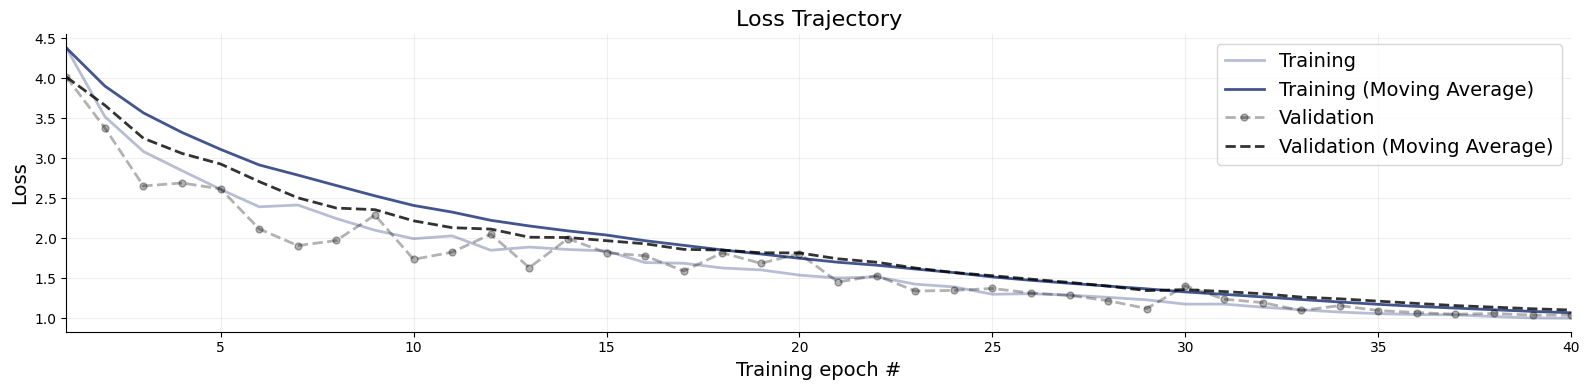

In [32]:
# 
# 7. Diagnostics
# 

par_names = [r"$\beta_0$", r"$\sigma^2_w$", r"$\eta_{raw}$", r"$\eta$", r"$\rho$"]#, "mean_deg", "mean_lag", "mean_diff"

# Loss curve
f = bf.diagnostics.plots.loss(history)

plt.savefig(IMAGES_DIR / f"history_plot_{ARTIFACT_STEM}.png",
            dpi=150, bbox_inches="tight")
print("History plot saved.")
